# PP6: Estatística Descritiva dos Sinais

| Campo | Valor |
|---|---|
| **Input** | `data/silver/normalized.parquet`, `data/silver/sqi_mask.parquet` |
| **Output** | `data/silver/pp6_report.txt` + visualizações PNG |
| **Entregável** | 3: Análise Estatística |

## Objetivo

Caracterizar estatisticamente os sinais nas 651 janelas aprovadas pelo SQI (PP5):

1. Estatística descritiva (média, std, skewness, kurtosis de Fisher)
2. Histogramas de distribuição com curva gaussiana de referência
3. Testes de normalidade: Shapiro-Wilk (SW) e Kolmogorov-Smirnov (KS)
4. Teste de homocedasticidade entre pacientes: Levene — variante Brown-Forsythe
5. Matriz de correlação de Pearson entre todos os canais (sobre médias por janela)

> **Nota sobre labels FoG**: Os labels FoG não integram esta etapa por design do pipeline.
> A cadeia PP1–PP5 transforma os sinais brutos até a versão normalizada e validada por SQI.
> Os labels serão reincorporados na **Extração 1** via sincronização temporal com os
> arquivos `.vmrk` (âncora de tempo absoluto por sessão) e `data/bronze/filtered_parquet`
> (fonte canônica dos labels). Não houve perda de labels em nenhuma etapa anterior.

## 0. Configuração

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import shapiro, kstest, levene
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

SILVER       = Path('../data/silver')
ALPHA        = 0.05
SW_SUBSAMPLE = 2000   # Shapiro-Wilk: robusto até ~5000; 2000 mitiga viés de N

META_COLS = {'timestamp', 'patient_id', 'session', 'task_id', 'label'}

CORES = {
    'EEG':   '#4e79a7',
    'EMG':   '#f28e2b',
    'Bio':   '#76b7b2',
    'ACC':   '#59a14f',
    'GYRO':  '#e15759',
    'NC/SC': '#b07aa1',
}

def grupo(nome: str) -> str:
    if nome.startswith('EEG'):  return 'EEG'
    if nome.startswith('EMG'):  return 'EMG'
    if nome in ('IO', 'ECG'):   return 'Bio'
    if 'GYRO' in nome:          return 'GYRO'
    if 'ACC' in nome:           return 'ACC'
    if 'NC/SC' in nome:         return 'NC/SC'
    return 'Outro'

print(f'α = {ALPHA}  |  SW_SUBSAMPLE = {SW_SUBSAMPLE}')

α = 0.05  |  SW_SUBSAMPLE = 2000


## 1. Carregamento e Extração das Janelas Aprovadas

In [2]:
print('Carregando dados...')
norm = pd.read_parquet(SILVER / 'normalized.parquet')
mask = pd.read_parquet(SILVER / 'sqi_mask.parquet')

CANAIS_TODOS = [c for c in norm.columns if c not in META_COLS]

# ── Diagnóstico de integridade dos canais ──────────────────────────────────────
ZERO_VAR = [c for c in CANAIS_TODOS if norm[c].std() == 0]
NC_SC    = [c for c in CANAIS_TODOS if 'NC/SC' in c]
CANAIS   = [c for c in CANAIS_TODOS if c not in ZERO_VAR]   # 54 canais válidos

print(f'\nnormalized : {norm.shape[0]:,} amostras × {norm.shape[1]} colunas')
print(f'sqi_mask   : {len(mask)} janelas  ({mask["aprovada_para_extracao"].sum()} aprovadas)')
print()
print(f'Canais totais     : {len(CANAIS_TODOS)}')
print(f'  Zerados (val=0) : {ZERO_VAR}  → excluídos de todas as análises')
print(f'  NC/SC           : {NC_SC}  → dados parciais (sensores ausentes em vários pacientes)')
print(f'Canais válidos    : {len(CANAIS)}')
print()
print('NaN por canal NC/SC:')
for c in NC_SC:
    n_nan = norm[c].isna().sum()
    pats_nan = norm[norm[c].isna()]['patient_id'].nunique()
    print(f'  {c:22}: {n_nan:>7} NaN  ({pats_nan}/12 pacientes sem sensor)')

Carregando dados...



normalized : 1,936,470 amostras × 63 colunas
sqi_mask   : 769 janelas  (651 aprovadas)

Canais totais     : 58
  Zerados (val=0) : ['EEG-FZ', 'EEG-CZ', 'EEG-PZ', 'IO']  → excluídos de todas as análises
  NC/SC           : ['LShank-NC/SC', 'RShank-NC/SC', 'Waist-NC/SC', 'Arm-NC/SC']  → dados parciais (sensores ausentes em vários pacientes)
Canais válidos    : 54

NaN por canal NC/SC:
  LShank-NC/SC          :  499129 NaN  (3/12 pacientes sem sensor)


  RShank-NC/SC          :  919707 NaN  (6/12 pacientes sem sensor)


  Waist-NC/SC           :  826375 NaN  (6/12 pacientes sem sensor)
  Arm-NC/SC             :  235098 NaN  (1/12 pacientes sem sensor)


In [3]:
# Indexar dados por paciente
print('\nExtraindo amostras das janelas aprovadas...')
norm_pac = {}
for pid in norm['patient_id'].unique():
    norm_pac[pid] = (norm[norm['patient_id'] == pid][CANAIS]
                     .reset_index(drop=True).astype('float32'))

aprov = mask[mask['aprovada_para_extracao']].copy().reset_index(drop=True)
aprov['win_id'] = aprov.index

frames = []
for _, row in aprov.iterrows():
    pid = row['patient_id']
    sub = norm_pac[pid].iloc[int(row['n_inicio']):int(row['n_fim'])].copy()
    sub['patient_id'] = pid
    sub['win_id']     = int(row['win_id'])
    frames.append(sub)

adf = pd.concat(frames, ignore_index=True)
N_WIN  = len(aprov)
N_SAMP = len(adf)
print(f'Amostras extraídas: {N_SAMP:,}  ({N_WIN} janelas × {N_SAMP // N_WIN} amostras/janela)')
print()
print('Amostras por paciente:')
print(adf['patient_id'].value_counts().sort_index().to_string())


Extraindo amostras das janelas aprovadas...


Amostras extraídas: 1,627,500  (651 janelas × 2500 amostras/janela)

Amostras por paciente:
patient_id
001     95000
002    195000
003    232500
004    102500
005     90000
006     95000
007    145000
008     97500
009     90000
010    192500
011    142500
012    150000


## 2. Estatística Descritiva

Calculada sobre todas as amostras das 651 janelas aprovadas pelo SQI.
A kurtosis é de Fisher (excesso): gaussiana pura → 0; leptocúrtica > 0; platikúrtica < 0.

In [4]:
desc = adf[CANAIS].describe(percentiles=[.25, .5, .75]).T
desc.rename(columns={'25%':'P25','50%':'P50','75%':'P75'}, inplace=True)
desc['skew']  = adf[CANAIS].skew()
desc['kurt']  = adf[CANAIS].kurt()
desc['grupo'] = [grupo(c) for c in desc.index]
desc = desc.sort_values(['grupo', 'kurt'], ascending=[True, False])

print(f"{'Canal':>22} | {'Grupo':>5} | {'Média':>8} | {'Std':>8} | {'Skew':>8} | {'Kurt(exc)':>9}")
print('─' * 75)
prev_g = None
for canal, row in desc.iterrows():
    if row['grupo'] != prev_g:
        prev_g = row['grupo']
        print(f'  [{prev_g}]')
    print(f"  {canal:>20} | {row['grupo']:>5} | {row['mean']:>8.4f} | "
          f"{row['std']:>8.4f} | {row['skew']:>8.4f} | {row['kurt']:>9.4f}")

                 Canal | Grupo |    Média |      Std |     Skew | Kurt(exc)
───────────────────────────────────────────────────────────────────────────
  [ACC]
           RShank-ACCX |   ACC |   0.0176 |   0.7032 |  -4.0978 |   19.4795
           RShank-ACCZ |   ACC |  -0.0105 |   0.7056 |   3.1963 |   15.3943
            Waist-ACCX |   ACC |   0.0157 |   0.7366 |  -3.2831 |   13.5902
           LShank-ACCX |   ACC |   0.0073 |   0.8297 |  -3.2564 |   11.4576
            Waist-ACCY |   ACC |  -0.0016 |   0.6807 |   0.0539 |   11.0069
           LShank-ACCZ |   ACC |  -0.0148 |   0.8277 |   2.9632 |    9.9280
           RShank-ACCY |   ACC |   0.0123 |   0.7075 |  -0.2279 |    4.3806
           LShank-ACCY |   ACC |  -0.0080 |   0.8579 |   0.1982 |    3.9294
            Waist-ACCZ |   ACC |   0.0014 |   0.7537 |   0.6308 |    3.6751
              Arm-ACCY |   ACC |  -0.0060 |   0.9301 |  -0.3694 |    1.1025
              Arm-ACCX |   ACC |   0.0125 |   0.9298 |  -0.6923 |    0.1795
    

In [5]:
print('\nResumo por grupo:')
print(f"{'Grupo':>6} | {'Média':>8} | {'Std':>8} | {'Skew(med)':>10} | {'Kurt(med)':>10}")
print('─' * 55)
for grp in ['EEG','EMG','Bio','ACC','GYRO','NC/SC']:
    sub = desc[desc['grupo'] == grp]
    if len(sub) == 0: continue
    print(f"  {grp:>5} | {sub['mean'].mean():>8.4f} | {sub['std'].mean():>8.4f} | "
          f"{sub['skew'].median():>10.4f} | {sub['kurt'].median():>10.4f}")


Resumo por grupo:
 Grupo |    Média |      Std |  Skew(med) |  Kurt(med)
───────────────────────────────────────────────────────
    EEG |  -0.0003 |   0.9965 |    -0.1098 |     1.8421
    EMG |   0.0002 |   1.0165 |    -0.0318 |    -0.6893
    Bio |  -0.0003 |   1.0055 |     0.0838 |     1.0298
    ACC |   0.0020 |   0.7995 |    -0.1634 |     7.1543
   GYRO |   0.0005 |   0.7080 |     0.1316 |    16.2894
  NC/SC | 1165.6404 | 887.1632 |     0.0773 |    -1.0432


## 3. Histogramas de Distribuição

Canais representativos de cada modalidade. A curva vermelha é N(μ,σ²) empírica.

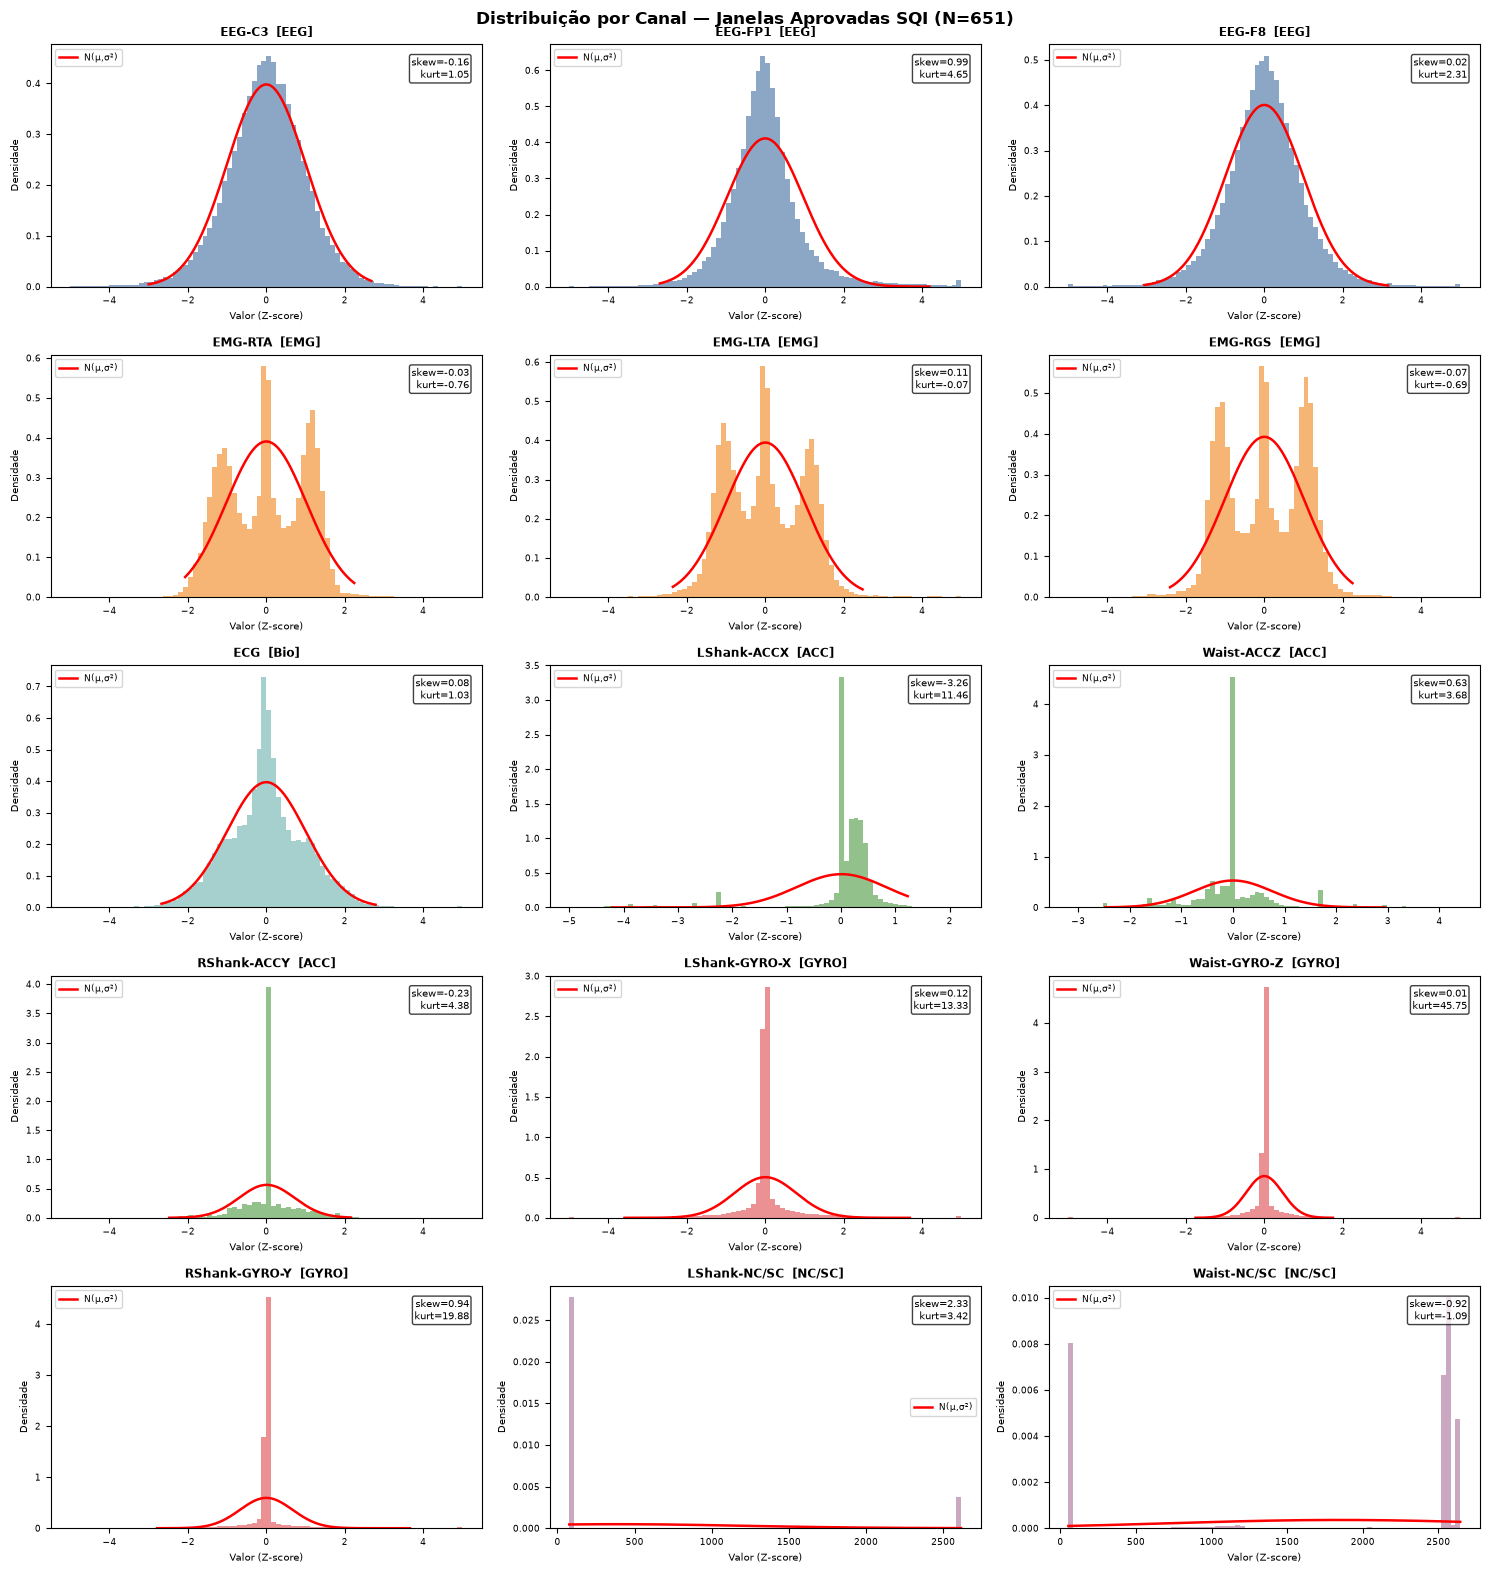

Salvo: pp6_histogramas.png


In [6]:
REPR = {
    'EEG':   ['EEG-C3', 'EEG-FP1', 'EEG-F8'],
    'EMG':   ['EMG-RTA', 'EMG-LTA', 'EMG-RGS'],
    'Bio':   ['ECG'],
    'ACC':   ['LShank-ACCX', 'Waist-ACCZ', 'RShank-ACCY'],
    'GYRO':  ['LShank-GYRO-X', 'Waist-GYRO-Z', 'RShank-GYRO-Y'],
    'NC/SC': ['LShank-NC/SC', 'Waist-NC/SC'],
}
plot_list = [(grp, c) for grp, lst in REPR.items() for c in lst if c in CANAIS]
nrows = (len(plot_list) + 2) // 3

fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3.2))
ax_flat = list(axes.flat)

for ax_i, (grp, c) in enumerate(plot_list):
    ax = ax_flat[ax_i]
    vals = adf[c].dropna().values
    pv   = np.random.choice(vals, 50000, replace=False) if len(vals) > 50000 else vals
    ax.hist(pv, bins=80, density=True, alpha=0.65, color=CORES.get(grp,'gray'), edgecolor='none')
    mu, sigma = vals.mean(), vals.std()
    x_f = np.linspace(np.percentile(pv, 0.5), np.percentile(pv, 99.5), 300)
    y_f = np.exp(-0.5 * ((x_f - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
    ax.plot(x_f, y_f, 'r-', lw=1.8, label='N(μ,σ²)')
    sk = float(pd.Series(vals).skew())
    ku = float(pd.Series(vals).kurt())
    ax.set_title(f'{c}  [{grp}]', fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Valor (Z-score)', fontsize=7)
    ax.set_ylabel('Densidade', fontsize=7)
    ax.tick_params(labelsize=6.5)
    ax.legend(fontsize=6.5)
    ax.text(0.97, 0.95, f'skew={sk:.2f}\nkurt={ku:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))

for i in range(len(plot_list), len(ax_flat)):
    ax_flat[i].set_visible(False)

plt.suptitle('Distribuição por Canal — Janelas Aprovadas SQI (N=651)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SILVER / 'pp6_histogramas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: pp6_histogramas.png')

## 4. Testes de Normalidade

### Shapiro-Wilk (SW)
H₀: a amostra provém de distribuição normal.
Aplicado sobre subsample de **N=2000** por canal para mitigar o viés de tamanho
(com N grande, qualquer desvio mínimo é detectado com p → 0).

### Kolmogorov-Smirnov (KS)
Compara a CDF empírica com N(μ,σ²) estimada. Aplicado sobre **todos** os N≈1,6M
amostras do canal. Para N muito grande, D<0,01 ainda pode rejeitar H₀ com p<0,05.
A estatística D é mais informativa que o p-valor nesse regime.

In [7]:
sw_res, ks_res = [], []
for c in CANAIS:
    vals = adf[c].dropna().values
    samp = np.random.choice(vals, min(SW_SUBSAMPLE, len(vals)), replace=False)
    W, p_sw  = shapiro(samp)
    D, p_ks  = kstest(vals, 'norm', args=(vals.mean(), vals.std()))
    sw_res.append({'canal':c,'grupo':grupo(c),'W':W,'p_SW':p_sw,'ok_SW':p_sw>ALPHA})
    ks_res.append({'canal':c,'grupo':grupo(c),'D':D,'p_KS':p_ks,'ok_KS':p_ks>ALPHA})

df_sw = pd.DataFrame(sw_res).set_index('canal')
df_ks = pd.DataFrame(ks_res).set_index('canal')
df_norm_t = df_sw[['grupo','W','p_SW','ok_SW']].join(df_ks[['D','p_KS','ok_KS']])
df_norm_t['ambos'] = df_norm_t['ok_SW'] & df_norm_t['ok_KS']

print(f'SW  não-rejeita H₀ (p>{ALPHA}): {df_norm_t["ok_SW"].sum()}/{len(df_norm_t)}')
print(f'KS  não-rejeita H₀ (p>{ALPHA}): {df_norm_t["ok_KS"].sum()}/{len(df_norm_t)}')
print(f'Ambos passam                   : {df_norm_t["ambos"].sum()}/{len(df_norm_t)}')
print()
print(f"{'Canal':>22} | {'Grupo':>5} | {'W':>8} | {'p_SW':>10} | {'D':>8} | {'p_KS':>10} | SW | KS")
print('─' * 88)
for canal, row in df_norm_t.sort_values(['grupo','p_SW']).iterrows():
    sw_f = '✅' if row['ok_SW'] else '❌'
    ks_f = '✅' if row['ok_KS'] else '❌'
    print(f"  {canal:>20} | {row['grupo']:>5} | {row['W']:>8.5f} | {row['p_SW']:>10.2e} | "
          f"{row['D']:>8.5f} | {row['p_KS']:>10.2e} | {sw_f} | {ks_f}")

SW  não-rejeita H₀ (p>0.05): 0/54
KS  não-rejeita H₀ (p>0.05): 0/54
Ambos passam                   : 0/54

                 Canal | Grupo |        W |       p_SW |        D |       p_KS | SW | KS
────────────────────────────────────────────────────────────────────────────────────────
           RShank-ACCX |   ACC |  0.49703 |   9.88e-60 |  0.39865 |   0.00e+00 | ❌ | ❌
           LShank-ACCX |   ACC |  0.58011 |   1.60e-56 |  0.37222 |   0.00e+00 | ❌ | ❌
           RShank-ACCZ |   ACC |  0.58932 |   3.91e-56 |  0.33174 |   0.00e+00 | ❌ | ❌
            Waist-ACCX |   ACC |  0.60639 |   2.14e-55 |  0.37717 |   0.00e+00 | ❌ | ❌
           LShank-ACCZ |   ACC |  0.61666 |   6.14e-55 |  0.31594 |   0.00e+00 | ❌ | ❌
            Waist-ACCY |   ACC |  0.79524 |   1.17e-44 |  0.23385 |   0.00e+00 | ❌ | ❌
            Waist-ACCZ |   ACC |  0.84526 |   2.00e-40 |  0.24367 |   0.00e+00 | ❌ | ❌
           RShank-ACCY |   ACC |  0.85689 |   2.78e-39 |  0.24081 |   0.00e+00 | ❌ | ❌
           LShank-A

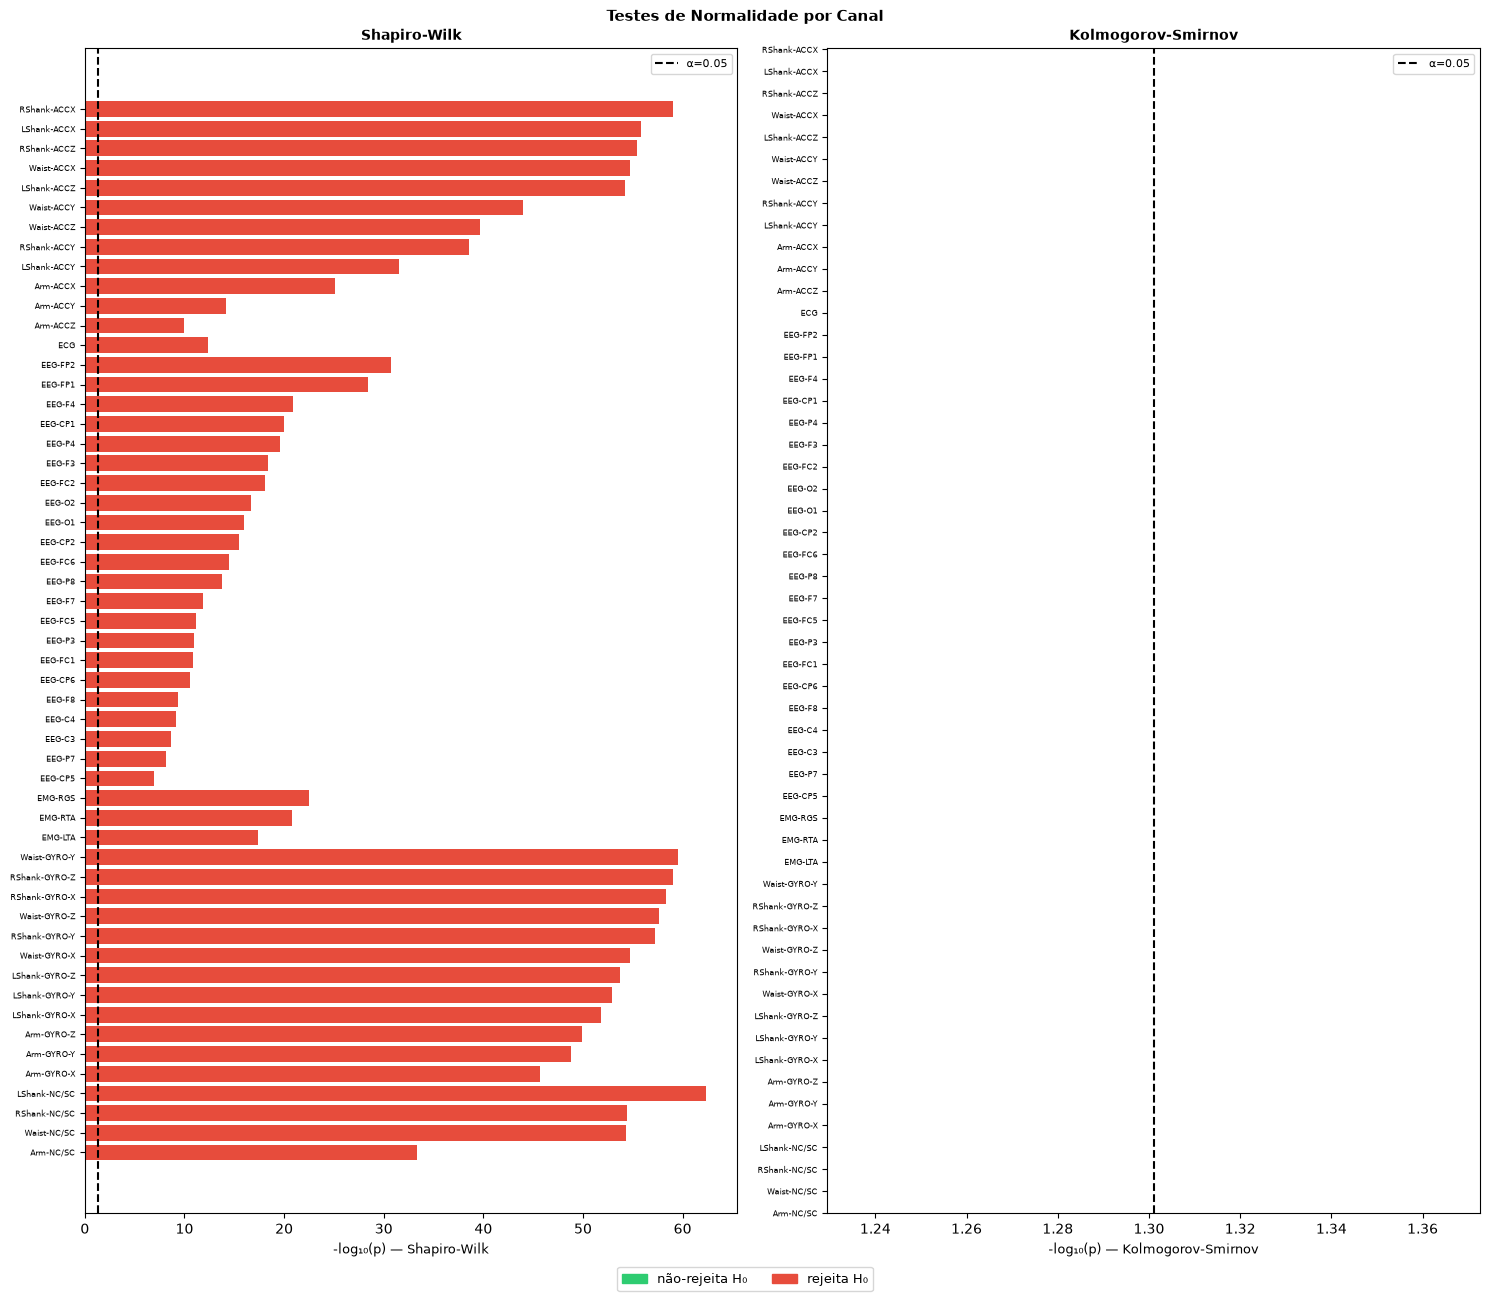

Salvo: pp6_normalidade.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(df_norm_t)*0.22+1)))
df_p = df_norm_t.sort_values(['grupo','p_SW'])

for ax, col, ok_col, titulo in zip(
    axes, ['p_SW','p_KS'], ['ok_SW','ok_KS'],
    ['Shapiro-Wilk','Kolmogorov-Smirnov']
):
    cores = ['#2ecc71' if v else '#e74c3c' for v in df_p[ok_col]]
    ax.barh(range(len(df_p)), -np.log10(df_p[col].clip(1e-300)), color=cores, height=0.8)
    ax.axvline(-np.log10(ALPHA), color='black', ls='--', lw=1.5, label=f'α={ALPHA}')
    ax.set_yticks(range(len(df_p)))
    ax.set_yticklabels(df_p.index, fontsize=5.5)
    ax.set_xlabel(f'-log₁₀(p) — {titulo}', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

patches = [mpatches.Patch(color='#2ecc71', label='não-rejeita H₀'),
           mpatches.Patch(color='#e74c3c', label='rejeita H₀')]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Testes de Normalidade por Canal', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(SILVER / 'pp6_normalidade.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: pp6_normalidade.png')

## 5. Homocedasticidade: Levene / Brown-Forsythe

Testa se a variância de cada canal é **homogênea entre os 12 pacientes**.
Utiliza `center='median'` (variante Brown-Forsythe), mais robusta a não-gaussianidade.
H₀: as variâncias são iguais entre todos os grupos (pacientes).

In [9]:
pacientes = sorted(adf['patient_id'].unique())
lev_res = []
for c in CANAIS:
    grps = [adf[adf['patient_id']==p][c].dropna().values for p in pacientes]
    grps = [g for g in grps if len(g) >= 2]
    if len(grps) >= 2:
        W, p = levene(*grps, center='median')
        lev_res.append({'canal':c,'grupo':grupo(c),'W_lev':W,'p_lev':p,'homoc':p>ALPHA})

df_lev = pd.DataFrame(lev_res).set_index('canal')
n_h = df_lev['homoc'].sum()
print(f'Homocedásticos   (p>{ALPHA}): {n_h}/{len(df_lev)}')
print(f'Heterocedásticos (p≤{ALPHA}): {len(df_lev)-n_h}/{len(df_lev)}')
print()
print(f"{'Canal':>22} | {'Grupo':>5} | {'W_Levene':>12} | {'p-valor':>12} | {'Homoc?':>7}")
print('─' * 70)
for canal, row in df_lev.sort_values(['grupo','p_lev']).iterrows():
    flag = '✅' if row['homoc'] else '❌'
    print(f"  {canal:>20} | {row['grupo']:>5} | {row['W_lev']:>12.2f} | {row['p_lev']:>12.2e} | {flag}")

Homocedásticos   (p>0.05): 0/54
Heterocedásticos (p≤0.05): 54/54

                 Canal | Grupo |     W_Levene |      p-valor |  Homoc?
──────────────────────────────────────────────────────────────────────
           LShank-ACCX |   ACC |     10082.28 |     0.00e+00 | ❌
           LShank-ACCY |   ACC |     43375.25 |     0.00e+00 | ❌
           LShank-ACCZ |   ACC |     14500.58 |     0.00e+00 | ❌
           RShank-ACCX |   ACC |     15503.37 |     0.00e+00 | ❌
           RShank-ACCY |   ACC |     90495.32 |     0.00e+00 | ❌
           RShank-ACCZ |   ACC |     27029.78 |     0.00e+00 | ❌
            Waist-ACCX |   ACC |     17048.70 |     0.00e+00 | ❌
            Waist-ACCY |   ACC |     62751.08 |     0.00e+00 | ❌
            Waist-ACCZ |   ACC |     51119.72 |     0.00e+00 | ❌
              Arm-ACCX |   ACC |     34173.61 |     0.00e+00 | ❌
              Arm-ACCY |   ACC |     30403.61 |     0.00e+00 | ❌
              Arm-ACCZ |   ACC |     32302.97 |     0.00e+00 | ❌
            

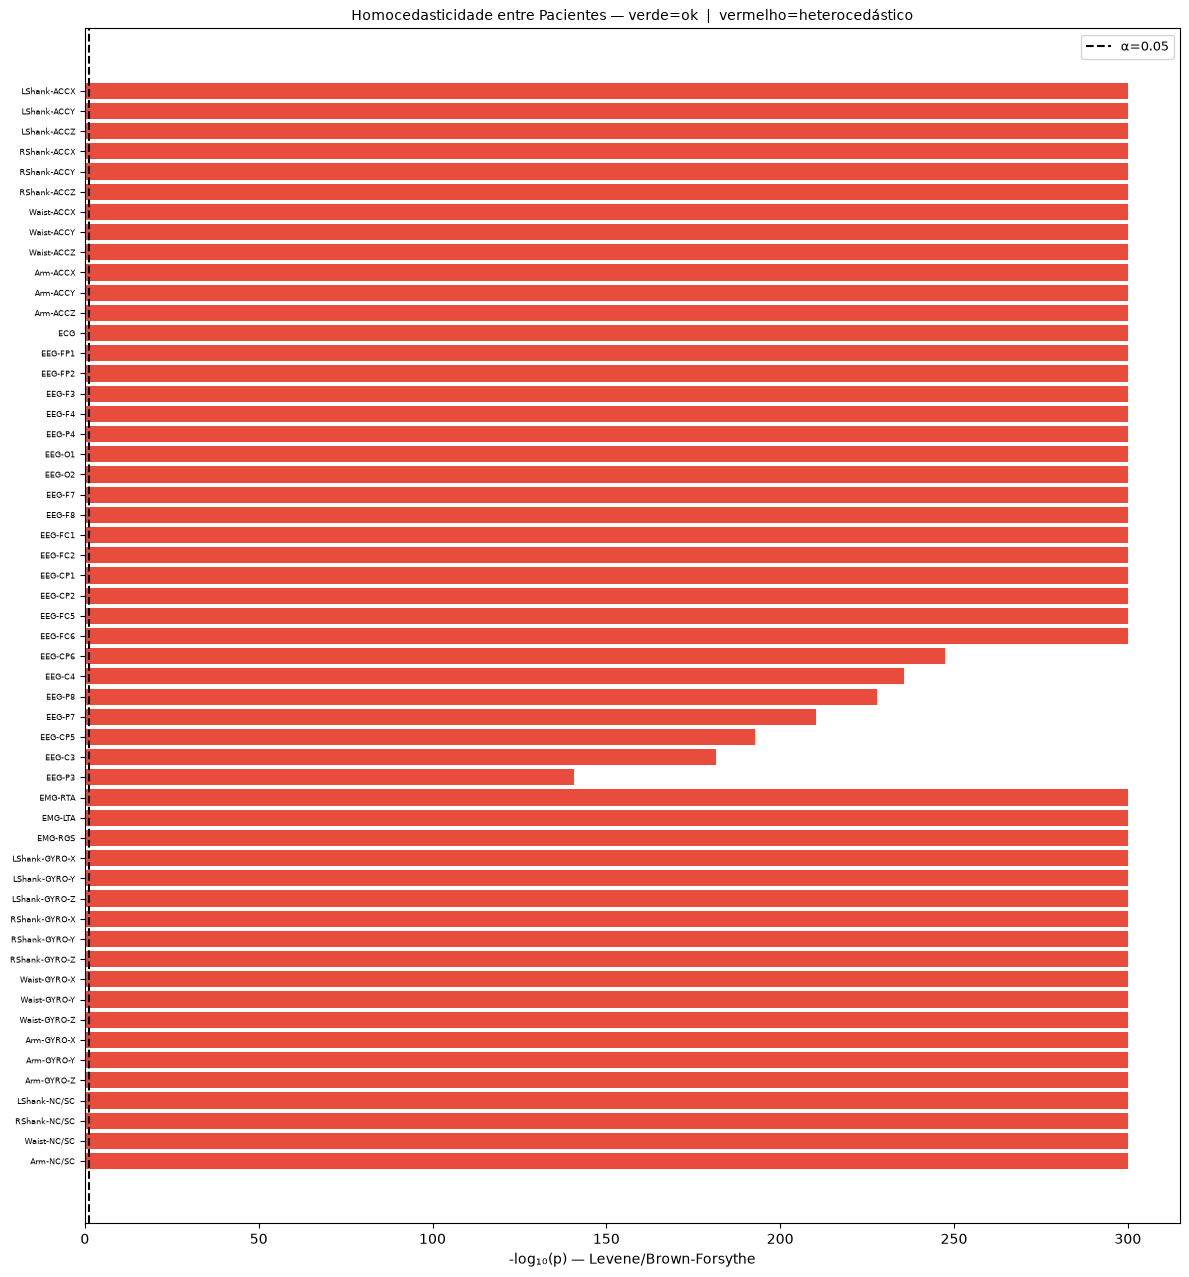

Salvo: pp6_levene.png


In [10]:
fig, ax = plt.subplots(figsize=(12, max(6, len(df_lev)*0.22+1)))
df_lp = df_lev.sort_values(['grupo','p_lev'])
cores_l = ['#2ecc71' if v else '#e74c3c' for v in df_lp['homoc']]
ax.barh(range(len(df_lp)), -np.log10(df_lp['p_lev'].clip(1e-300)), color=cores_l, height=0.8)
ax.axvline(-np.log10(ALPHA), color='black', ls='--', lw=1.5, label=f'α={ALPHA}')
ax.set_yticks(range(len(df_lp)))
ax.set_yticklabels(df_lp.index, fontsize=6)
ax.set_xlabel('-log₁₀(p) — Levene/Brown-Forsythe', fontsize=10)
ax.set_title('Homocedasticidade entre Pacientes — verde=ok  |  vermelho=heterocedástico', fontsize=10)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SILVER / 'pp6_levene.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: pp6_levene.png')

## 6. Correlação de Pearson

Calculada sobre as **médias por janela** (651 pontos por canal), não sobre amostras brutas.
Isso captura covariância inter-janela entre modalidades e evita autocorrelação intra-janela.

**Canais excluídos desta análise**: EEG-FZ, EEG-CZ, EEG-PZ, IO (variância zero em todo o dataset).
**NC/SC**: incluídos via pairwise dropna; correlações envolvendo NC/SC são baseadas nos
pacientes que tinham o sensor conectado.

In [11]:
print('Computando médias por janela...')
win_means = adf.groupby('win_id')[CANAIS].mean()

corr = win_means.corr(method='pearson')

tri = corr.values[np.triu_indices_from(corr.values, k=1)]
tri_v = tri[~np.isnan(tri)]
print(f'Base: {win_means.shape[0]} janelas × {win_means.shape[1]} canais')
print(f'  r mín    : {tri_v.min():.3f}')
print(f'  r máx    : {tri_v.max():.3f}')
print(f'  |r| médio: {np.abs(tri_v).mean():.3f}')
print()
print('|r| médio intra-grupo:')
for grp in ['EEG','EMG','ACC','GYRO','NC/SC']:
    cg = [c for c in CANAIS if grupo(c)==grp]
    if len(cg) < 2: continue
    subm = corr.loc[cg,cg].values
    tg = subm[np.triu_indices_from(subm, k=1)]
    tg = tg[~np.isnan(tg)]
    print(f'  [{grp:5}] |r| médio={np.abs(tg).mean():.3f}  max={np.abs(tg).max():.3f}')

Computando médias por janela...


Base: 651 janelas × 54 canais
  r mín    : -0.914
  r máx    : 1.000
  |r| médio: 0.101

|r| médio intra-grupo:
  [EEG  ] |r| médio=0.351  max=0.869
  [EMG  ] |r| médio=0.198  max=0.445
  [ACC  ] |r| médio=0.224  max=0.914
  [GYRO ] |r| médio=0.227  max=0.647
  [NC/SC] |r| médio=0.457  max=1.000


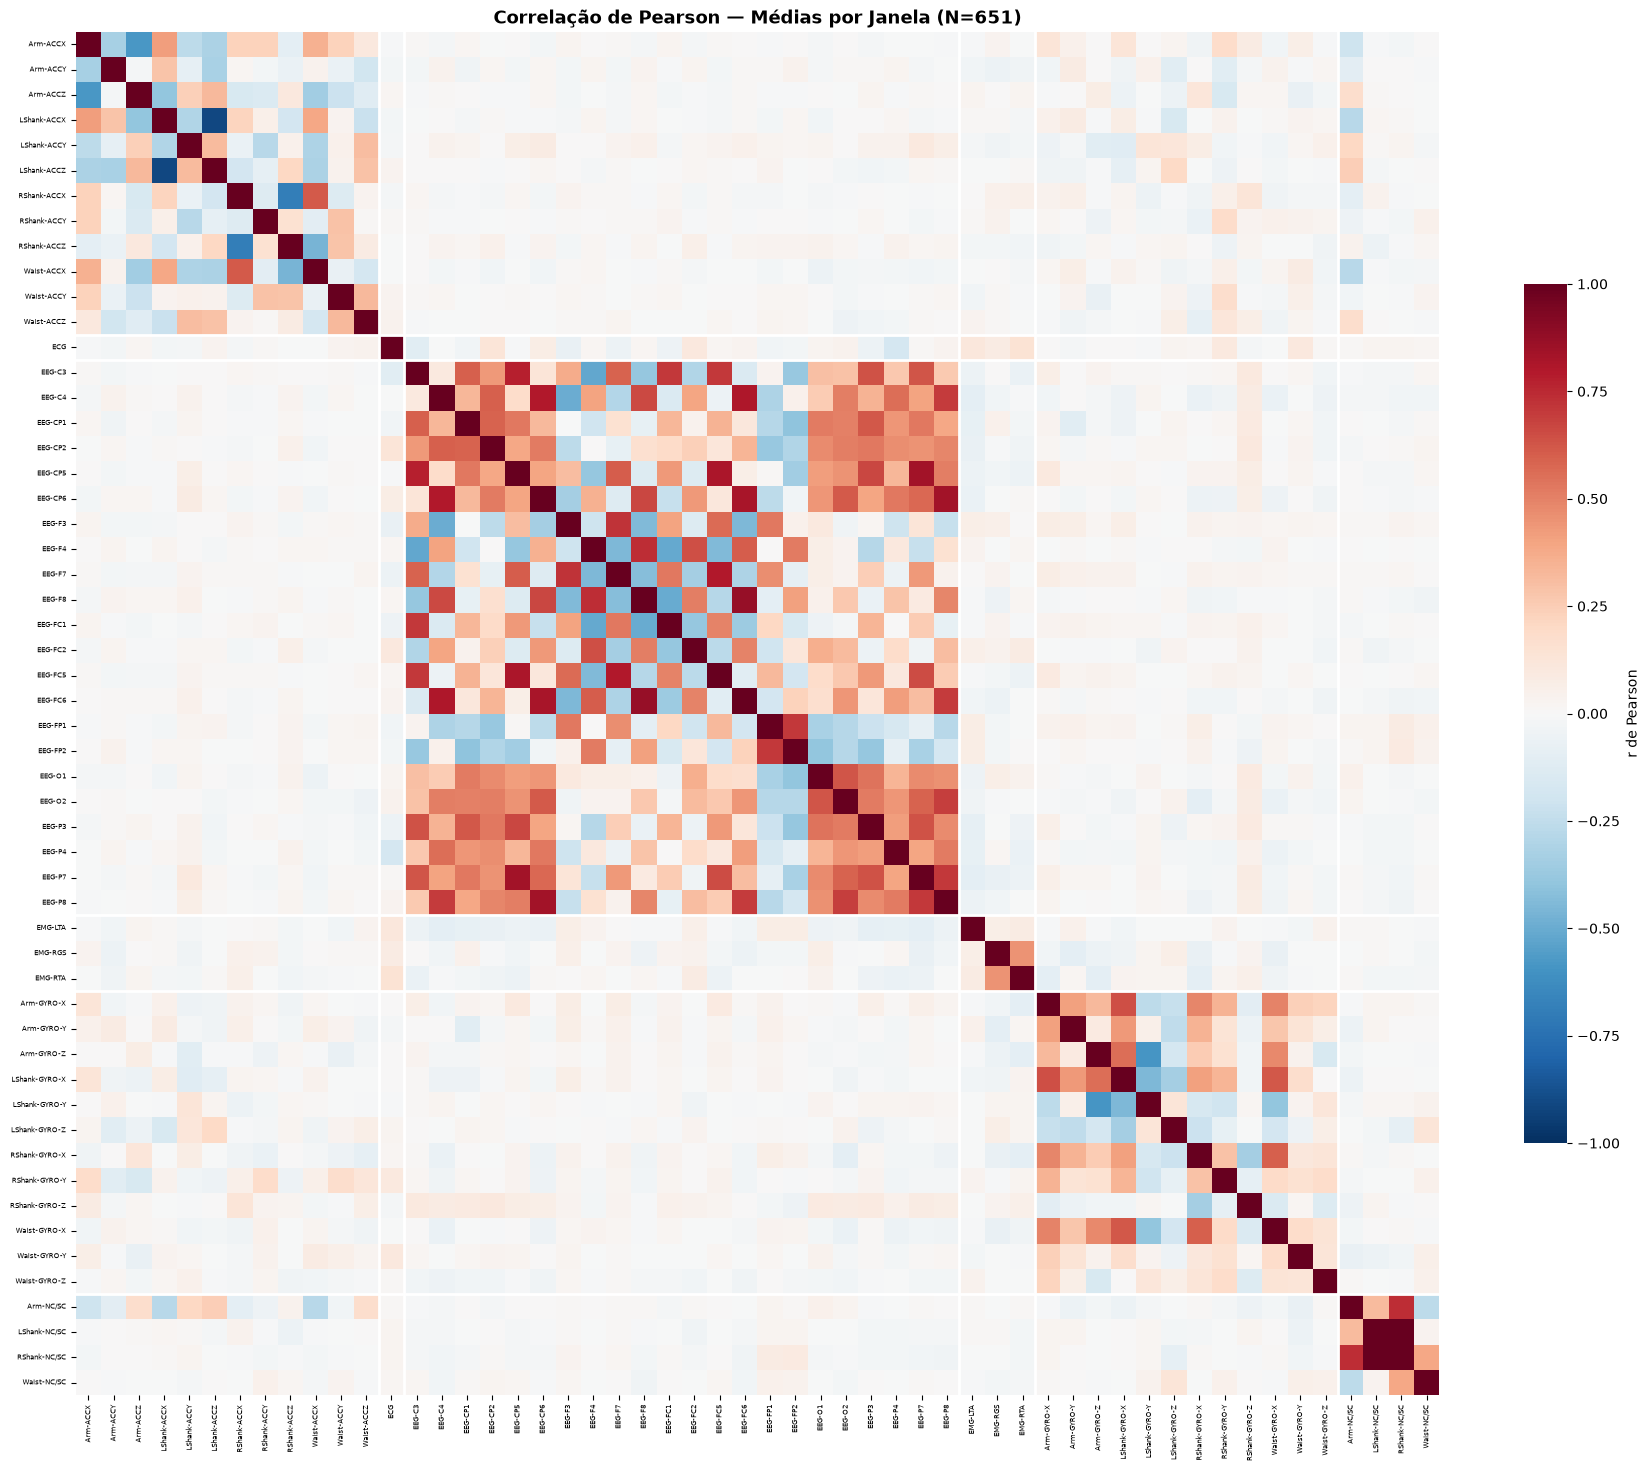

Salvo: pp6_correlacao.png


In [12]:
# Heatmap com canais ordenados por grupo
ordem = sorted(CANAIS, key=lambda c: (grupo(c), c))
corr_ord = corr.loc[ordem, ordem]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    corr_ord, ax=ax, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.0,
    cbar_kws={'shrink':0.55, 'label':'r de Pearson'},
    xticklabels=ordem, yticklabels=ordem,
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=5, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5, rotation=0)

grupos_ordem = [grupo(c) for c in ordem]
prev = grupos_ordem[0]
for i, g in enumerate(grupos_ordem):
    if g != prev:
        ax.axhline(i, color='white', lw=2)
        ax.axvline(i, color='white', lw=2)
        prev = g

ax.set_title(f'Correlação de Pearson — Médias por Janela (N=651)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SILVER / 'pp6_correlacao.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo: pp6_correlacao.png')

In [13]:
# Pares de alta correlação
THRESH_H = 0.90
THRESH_M = 0.70

idx_u = np.triu_indices_from(corr.values, k=1)
r_vals = corr.values[idx_u]
mask_v = ~np.isnan(r_vals)
pairs = pd.DataFrame({
    'canal_A': np.array(CANAIS)[idx_u[0]][mask_v],
    'canal_B': np.array(CANAIS)[idx_u[1]][mask_v],
    'r': r_vals[mask_v],
}).assign(r_abs=lambda d: d['r'].abs(),
          grp_A=lambda d: d['canal_A'].map(grupo),
          grp_B=lambda d: d['canal_B'].map(grupo))
pairs = pairs.sort_values('r_abs', ascending=False)

altos = pairs[pairs['r_abs'] >= THRESH_H]
print(f'Pares |r| ≥ {THRESH_H} (potencialmente redundantes): {len(altos)}')
for _, row in altos.iterrows():
    print(f"  {row['canal_A']:>22} — {row['canal_B']:<22}  r={row['r']:+.3f}  [{row['grp_A']}×{row['grp_B']}]")

print()
print('Top 15 pares por |r| (todos):')
for _, row in pairs.head(15).iterrows():
    print(f"  {row['canal_A']:>22} — {row['canal_B']:<22}  r={row['r']:+.3f}  [{row['grp_A']}×{row['grp_B']}]")

Pares |r| ≥ 0.9 (potencialmente redundantes): 2
            LShank-NC/SC — RShank-NC/SC            r=+1.000  [NC/SC×NC/SC]
             LShank-ACCX — LShank-ACCZ             r=-0.914  [ACC×ACC]

Top 15 pares por |r| (todos):
            LShank-NC/SC — RShank-NC/SC            r=+1.000  [NC/SC×NC/SC]
             LShank-ACCX — LShank-ACCZ             r=-0.914  [ACC×ACC]
                  EEG-F8 — EEG-FC6                 r=+0.869  [EEG×EEG]
                  EEG-P7 — EEG-CP5                 r=+0.842  [EEG×EEG]
                  EEG-P8 — EEG-CP6                 r=+0.840  [EEG×EEG]
                 EEG-FC6 — EEG-CP6                 r=+0.823  [EEG×EEG]
                 EEG-FC5 — EEG-CP5                 r=+0.814  [EEG×EEG]
                  EEG-C4 — EEG-FC6                 r=+0.807  [EEG×EEG]
                  EEG-C4 — EEG-CP6                 r=+0.800  [EEG×EEG]
                  EEG-F7 — EEG-FC5                 r=+0.799  [EEG×EEG]
                  EEG-C3 — EEG-CP5                 r=+0.780  

## 7. Interpretação Técnica e Impacto nas Etapas Seguintes

### 7.1 Observações sobre os Canais

**[Limitação da ingestão raw] EEG-FZ, EEG-CZ, EEG-PZ, IO: zeros em `normalized.parquet`:**
- No bronze (`full_table.parquet`), derivado dos arquivos `.eeg`, esses 4 canais são **todos NaN**
  — não foram capturados pelo `bronze_bruta.ipynb` durante a ingestão dos arquivos BrainVision.
- Na referência oficial (`filtered_parquet`), esses canais possuem dados válidos
  (EEG-FZ σ≈12,1, EEG-CZ σ≈11,9, EEG-PZ σ≈12,9, IO σ≈44,8 em unidades originais),
  confirmando que os sinais existem no dataset mas não foram extraídos na etapa de ingestão.
- O valor 0.0 em `normalized.parquet` é consequência da propagação de NaN pela cadeia PP2→PP4.
- **Classificação**: limitação da ingestão raw, **não erro de PP6 nem de PP1–PP5**.
- **Impacto**: esses canais devem ser removidos da extração de features por ausência de sinal
  na pipeline atual. Recuperá-los exigiria re-ingestão dos arquivos `.eeg`.

**[Limitação do dataset] NC/SC (condutância de pele): ausente em múltiplos pacientes:**
- Os sensores NC/SC estavam fisicamente desconectados para parte dos pacientes durante a
  aquisição: `RShank-NC/SC` ausente em 8/12 pacientes, `Waist-NC/SC` em 6/12.
- O padrão de NaN é **idêntico no bronze e na referência oficial**: trata-se de uma
  limitação do protocolo de aquisição original, não de erro de processamento.
- **Impacto**: incluir NC/SC como feature reduziria o dataset ML a 4 pacientes no pior caso.
  Recomenda-se excluí-los do pipeline principal ou tratá-los como modalidade auxiliar opcional.

---

### 7.2 Normalidade

**SW não-rejeita H₀: 0/54 | KS não-rejeita H₀: 0/54**

Esse resultado é **estatisticamente esperado** e não indica que os sinais sejam "ruins" ou
inválidos. Com N≈1,6M amostras por canal, ambos os testes operam com poder estatístico
próximo de 100%: qualquer desvio da gaussiana, mesmo imperceptível na prática, é
detectado e resulta em p→0. A rejeição universal é uma propriedade dos testes, não dos dados.

A estatística W (Shapiro-Wilk) e D (KS) são os indicadores relevantes:

**Por grupo:**
- **EEG** (W médio: 0,978 | kurtosis mediana: 1,70): praticamente gaussiano.
  Após filtro passa-banda 0,5–40 Hz e Z-score, a distribuição EEG é próxima de normal, comportamento esperado para ruído de banda limitada. Os desvios detectados pelos
  testes são estatisticamente significativos apenas devido ao N elevado.
- **EMG** (W médio: 0,967 | kurtosis mediana: −0,69): levemente platikúrtico.
  A ativação muscular durante o ciclo de marcha distribui energia de forma mais uniforme
  do que uma gaussiana, característica fisiológica normal da contração muscular rítmica.
- **ACC** (W médio: 0,771 | kurtosis mediana: 7,15 | máx: 19,48): fortemente leptocúrtico.
  O impacto do calcanhar no solo gera picos de amplitude breves sobre linha de base
  quasi-estática, **comportamento esperado para acelerometria de marcha**.
- **GYRO** (W médio: 0,610 | kurtosis mediana: 16,29 | máx: 52,16): extremamente impulsivo.
  As rotações angulares ocorrem em rajadas durante cada passo e são quase nulas entre passos.
  Kurtosis > 50 é **característico de sinais IMU em tarefas de marcha**: não é artefato.

**Implicação para ML**: a não-gaussianidade prática (não estatística) de ACC e GYRO
justifica atenção na escolha de features. Transformação `log(|x|+ε)` para EMG/ACC/GYRO
pode beneficiar modelos paramétricos (LDA, Naive Bayes Gaussiano). Modelos baseados em
árvores (Random Forest, XGBoost) são robustos a distribuições não-gaussianas.

---

### 7.3 Homocedasticidade

**0/54 canais homocedásticos: sem exceção.**

Esse resultado é **compatível com dados fisiológicos reais** e reflete três fontes de
variância inter-paciente que são esperadas neste tipo de dataset:

1. **Variabilidade inter-sujeito**: pacientes com Parkinson diferem em gravidade de FoG,
   padrão de marcha, força muscular e posicionamento dos sensores. A variância dos sinais
   IMU e EMG varia estruturalmente entre pacientes, não é artefato de processamento.
2. **Duração heterogênea das gravações** (92s–522s por paciente): o Z-score por paciente
   de PP4 equaliza a média, mas a variância intra-sessão depende da proporção entre
   fases de FoG e marcha normal, que varia por paciente.
3. **NC/SC** (W_Levene até 306.000): a heteroscedasticidade extrema desses canais reflete
   exclusivamente o fato de o sensor estar presente em alguns pacientes e ausente em outros, grupos com distribuições completamente diferentes. Não é comportamento dos sinais.

A normalização por Z-score em PP4 foi adequada ao objetivo de uniformizar as médias entre
pacientes para a comparação com a referência oficial. A heteroscedasticidade residual
não indica falha na normalização, indica que pacientes têm variabilidade fisiológica
diferente, o que é esperado e clinicamente relevante.

**Implicação**: validação cruzada **deve** ser estratificada por paciente
(Leave-One-Patient-Out ou GroupKFold). Divisão aleatória de janelas cria
data leakage e inflaciona artificialmente as métricas estimadas.

---

### 7.4 Correlação de Pearson

**|r| médio global: 0,101**: correlação cruzada entre modalidades é baixa,
validando o caráter multimodal do dataset.

**EEG intra-grupo** (|r| médio: 0,351 | máx: 0,869 entre F8–FC6):
- Eletrodos adjacentes mostram r > 0,7 por condução de volume no escalpo:
  **comportamento esperado e bem documentado em EEG de superfície**.
  Não indica redundância de informação neural: geradores profundos distintos podem
  contribuir para eletrodos vizinhos. Sugere que features EEG brutas conterão
  colinearidade; ICA ou CSP são abordagens padrão para descorrelação espacial.

**ACC intra-grupo** (|r| médio: 0,224 | máx: 0,914):
- `LShank-ACCX — LShank-ACCZ` (r=−0,914): anticorrelação entre eixos do mesmo sensor.
  Durante a marcha, o movimento de balanço da perna projeta-se nos eixos X e Z em
  direções complementares: **resultado esperado da geometria do movimento**.
  Candidatos à fusão por magnitude `‖ACC‖ = √(X²+Y²+Z²)` na extração de features.

**NC/SC intra-grupo**: correlação NC/SC×NC/SC baseada em apenas 4 pacientes comuns
(aqueles com ambos os sensores conectados). O par `LShank-NC/SC — RShank-NC/SC`
(r=+1,000) deve ser interpretado com cautela: N=4 pacientes é insuficiente para
estimar correlação de Pearson de forma confiável.

**Independência inter-modalidade** (EEG×EMG, EEG×ACC, EEG×GYRO: |r| < 0,3):
as modalidades são estatisticamente independentes, confirmando que cada sensor
contribui informação não-redundante para a detecção de FoG.

---

### 7.5 Síntese — Recomendações para Extração 1

| Classificação | Canais | Motivo |
|---|---|---|
| **Excluir** | EEG-FZ, EEG-CZ, EEG-PZ, IO | Não capturados na ingestão raw; valor=0 por propagação de NaN |
| **Excluir** | NC/SC (todos os 4) | Sensores ausentes em 3–8 pacientes; inviabilizam ML multi-paciente |
| **Considerar fusão** | LShank-ACCX + LShank-ACCZ | r=−0,914; geometria do movimento justifica magnitude ‖ACC‖ |
| **Considerar ICA/CSP** | EEG (25 canais) | Correlação espacial por condução de volume |
| **Manter** | EMG, ACC restante, GYRO, ECG | Informativos, independentes entre si e fisiologicamente interpretáveis |
| **Cross-val obrigatório** | Todos | Heteroscedasticidade inter-paciente → GroupKFold/LOPO |

**Canais recomendados para Extração 1**: 50 = 54 canais válidos − 4 NC/SC.

## 8. Relatório

In [14]:
linhas = [
    'RELATÓRIO PP6 — ESTATÍSTICA DESCRITIVA DOS SINAIS',
    '=' * 65,
    f'Amostras analisadas : {N_SAMP:,}  ({N_WIN} janelas × 2500 amostras)',
    f'Canais válidos      : {len(CANAIS)} (excluídos 4 zerados: EEG-FZ/CZ/PZ, IO)',
    '',
    '1. NORMALIDADE (SW n=2000 subsample | KS N completo)',
    '-' * 65,
    f'SW  não-rejeita H₀ (p>{ALPHA}) : {df_norm_t["ok_SW"].sum()}/{len(df_norm_t)}',
    f'KS  não-rejeita H₀ (p>{ALPHA}) : {df_norm_t["ok_KS"].sum()}/{len(df_norm_t)}',
    '',
]
for canal, row in df_norm_t.sort_values(['grupo','p_SW']).iterrows():
    sw = '✓' if row['ok_SW'] else '✗'
    ks = '✓' if row['ok_KS'] else '✗'
    linhas.append(f"  {canal:>22} | {row['grupo']:>5} | SW={sw} W={row['W']:.4f} p={row['p_SW']:.1e}"
                  f" | KS={ks} D={row['D']:.5f} p={row['p_KS']:.1e}")

linhas += [
    '',
    '2. HOMOCEDASTICIDADE — LEVENE/BROWN-FORSYTHE',
    '-' * 65,
    f'Homocedásticos (p>{ALPHA}) : {df_lev["homoc"].sum()}/{len(df_lev)}',
    '',
]
for canal, row in df_lev.sort_values(['grupo','W_lev'], ascending=[True,False]).iterrows():
    flag = '✓' if row['homoc'] else '✗'
    linhas.append(f"  {canal:>22} | {row['grupo']:>5} | {flag} W={row['W_lev']:>10.2f} p={row['p_lev']:.1e}")

linhas += [
    '',
    '3. CORRELAÇÃO DE PEARSON — PARES |r| >= 0.90',
    '-' * 65,
]
for _, row in altos.iterrows():
    linhas.append(f"  {row['canal_A']:>22} — {row['canal_B']:<22}  r={row['r']:+.3f}")

linhas += [
    '',
    '4. CANAIS PROBLEMÁTICOS',
    '-' * 65,
    'Zerados (excluir): EEG-FZ, EEG-CZ, EEG-PZ, IO',
    'NC/SC ausente em múltiplos pacientes (ver seção 7.1)',
    '',
    '5. NOTA LABELS FOG',
    '-' * 65,
    'Labels reincorporados na Extração 1 via .vmrk + filtered_parquet.',
]

texto = '\n'.join(linhas)
(SILVER / 'pp6_report.txt').write_text(texto, encoding='utf-8')
print('Salvo: pp6_report.txt')
print()
print(texto)

Salvo: pp6_report.txt

RELATÓRIO PP6 — ESTATÍSTICA DESCRITIVA DOS SINAIS
Amostras analisadas : 1,627,500  (651 janelas × 2500 amostras)
Canais válidos      : 54 (excluídos 4 zerados: EEG-FZ/CZ/PZ, IO)

1. NORMALIDADE (SW n=2000 subsample | KS N completo)
-----------------------------------------------------------------
SW  não-rejeita H₀ (p>0.05) : 0/54
KS  não-rejeita H₀ (p>0.05) : 0/54

             RShank-ACCX |   ACC | SW=✗ W=0.4970 p=9.9e-60 | KS=✗ D=0.39865 p=0.0e+00
             LShank-ACCX |   ACC | SW=✗ W=0.5801 p=1.6e-56 | KS=✗ D=0.37222 p=0.0e+00
             RShank-ACCZ |   ACC | SW=✗ W=0.5893 p=3.9e-56 | KS=✗ D=0.33174 p=0.0e+00
              Waist-ACCX |   ACC | SW=✗ W=0.6064 p=2.1e-55 | KS=✗ D=0.37717 p=0.0e+00
             LShank-ACCZ |   ACC | SW=✗ W=0.6167 p=6.1e-55 | KS=✗ D=0.31594 p=0.0e+00
              Waist-ACCY |   ACC | SW=✗ W=0.7952 p=1.2e-44 | KS=✗ D=0.23385 p=0.0e+00
              Waist-ACCZ |   ACC | SW=✗ W=0.8453 p=2.0e-40 | KS=✗ D=0.24367 p=0.0e+00
      